In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
from code.io import read_data
df = read_data("sdt", correct_galactic_extinction=True)

In [4]:
df

,magnitude,mag_error,wavelength,filter_width,is_upper_limit,filter_name,units,aperture_size,image_path,exposure,date_obs,cat_mag,cat_mag_err,aper_mag,aper_mag_err,extinction,corrected
0,17.893990,0.022500,4750,1150,False,g,7DT16,0.0000,/lyman/data2/too/2025-10-13/T19154/g/differenc...,300.0,2025-10-14T00:04:15.000,18.0910,0.0225,18.090775,0.030191,0.197010,True
1,17.693365,0.037400,6250,1150,False,r,7DT16,0.0000,/lyman/data2/too/2025-10-13/T19154/r/differenc...,300.0,2025-10-14T00:11:13.000,17.8274,0.0374,17.783325,0.072628,0.134035,True
2,17.206242,0.065900,7700,1000,False,i,7DT01,0.0000,/lyman/data2/too/2025-10-13/T19154/i/differenc...,300.0,2025-10-14T00:04:22.000,17.3029,0.0659,17.310494,0.103051,0.096658,True
3,18.384434,0.153300,4000,250,False,m400,7DT13,0.0000,/lyman/data2/too/2025-10-13/T19154/m400/differ...,300.0,2025-10-14T00:11:08.000,18.6177,0.1533,18.528180,0.162907,0.233266,True
4,18.034175,0.071500,4250,250,False,m425,7DT11,0.0000,/lyman/data2/too/2025-10-13/T19154/m425/differ...,300.0,2025-10-14T00:11:15.000,18.2558,0.0715,18.267887,0.084835,0.221625,True
5,17.824147,0.058300,4500,250,False,m450,7DT03,0.0000,/lyman/data2/too/2025-10-13/T19154/m450/differ...,300.0,2025-10-14T00:04:10.000,18.0339,0.0583,18.034111,0.064936,0.209753,True
6,17.848490,0.055200,4750,250,False,m475,7DT03,0.0000,/lyman/data2/too/2025-10-13/T19154/m475/differ...,300.0,2025-10-14T00:11:07.667,18.0455,0.0552,18.048221,0.064968,0.197010,True
7,18.069290,0.062300,5000,250,False,m500,7DT14,0.0000,/lyman/data2/too/2025-10-13/T19154/m500/differ...,300.0,2025-10-14T00:11:52.000,18.2531,0.0623,18.211888,0.064861,0.183810,True
8,17.715573,0.048300,5250,250,False,m525,7DT02,0.0000,/lyman/data2/too/2025-10-13/T19154/m525/differ...,300.0,2025-10-14T00:11:09.000,17.8869,0.0483,17.893740,0.059733,0.171327,True
9,17.692043,0.070000,5500,250,False,m550,7DT04,0.0000,/lyman/data2/too/2025-10-13/T19154/m550/differ...,300.0,2025-10-14T00:11:14.667,17.8523,0.0700,17.817090,0.070825,0.160257,True


In [10]:
host_extinction = host_galaxy_extinction("MW", z=REDSHIFT)

In [ ]:
from code.utils import wavelength_to_frequency,

ImportError: cannot import name 'galactic_extinction' from 'code.utils' (/data/dtak/research/grb/GRB251013C/code/utils.py)

In [ ]:
from code.extinction import galactic_extinction

In [15]:
nu = wavelength_to_frequency(df["wavelength"])
h_ext = host_extinction(nu)

In [15]:
from matplotlib import pyplot as plt

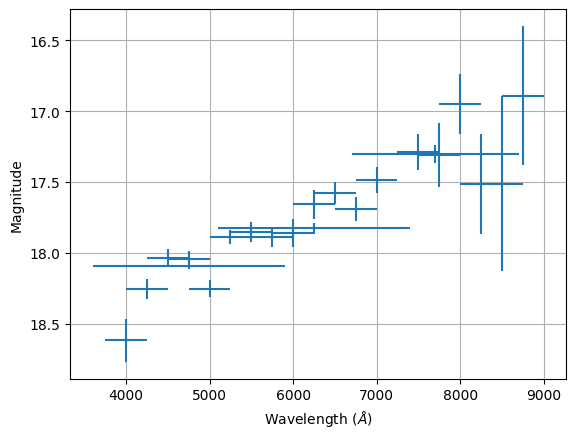

## XRT fit

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from code.io import read_data, filter_data
from code.const import TRIGGER_TIME
from code.analysis import Analyzer

from code.functions import *
from code.prior import *

from code.utils import mag_to_flux_jy
from code.lightcurve import prepare_lc_data, plot_lightcurve

In [11]:
df = read_data("xrt")
df = filter_data(df, exclude_time_range = (3e3,  1e4))
y_err = np.array([max(np.abs(high), np.abs(low)) for high, low in zip(df["Flux_high"], df["Flux_low"])])

alz_xrt = Analyzer(df["Time"]/3600, df["Flux"], power_law, y_data_error=y_err)
alz_xrt.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-2e+01   [-19.8749..-19.8749]*| it/evals=4590/91149 eff=5.0523% N=300     0 0 0 0 0 
[ultranest] Likelihood function evaluations: 91149
[ultranest]   logZ = -30.53 +- 0.1435
[ultranest] Effective samples strategy satisfied (ESS = 1197.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.18 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.


In [15]:
from code.prior import power_law_prior

In [17]:
param_bounds, prior = power_law_prior()

In [18]:
param_bounds["alpha"] = (alz_xrt.results["posterior"]["mean"][1], alz_xrt.results["posterior"]["stdev"][1])

In [20]:
prior["alpha"] = "norm"

In [21]:
param_bounds, prior

({'F_pl': (1e-15, 10.0), 'alpha': (1.0333681438478717, 0.02380856123679781)},
 {'F_pl': 'log_uniform', 'alpha': 'norm'})

In [13]:
alz_xrt.results

{'niter': 4891,
 'logz': -30.56485473419138,
 'logzerr': 0.3300032590531206,
 'logz_bs': -30.532998839264014,
 'logz_single': -30.56485473419138,
 'logzerr_tail': 0.00992677413117704,
 'logzerr_bs': 0.3298539224278372,
 'ess': 1197.071338011381,
 'H': 9.69879424737529,
 'Herr': 0.1375106429605555,
 'posterior': {'mean': [1.524355972978349e-11, 1.0333681438478717],
  'stdev': [6.037794988566428e-13, 0.02380856123679781],
  'median': [1.525387337687132e-11, 1.0322778856546277],
  'errlo': [1.4635480983891287e-11, 1.0099952866889592],
  'errup': [1.5839638546352922e-11, 1.0558777710009315],
  'information_gain_bits': [4.1150705820732485, 3.7917493552119823]},
 'weighted_samples': {'upoints': array([[0.97633074, 0.92946968],
         [0.9609973 , 0.85876456],
         [0.92050906, 0.96615255],
         ...,
         [0.26156319, 0.2058833 ],
         [0.26156613, 0.20595123],
         [0.26156966, 0.20588603]]),
  'points': array([[4.18111254e+00, 4.64734840e+00],
         [2.37660399e+00,

<Axes: xlabel='Time', ylabel='Flux'>

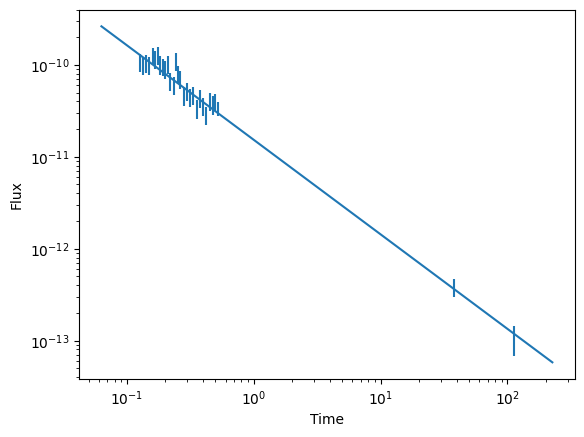

In [5]:
alz_xrt.plot_data()
alz_xrt.plot_model(color="C0")

## Ic band fit

In [ ]:
df = read_data("circular")
df = filter_data(df, filter_name=["Ic"], remove_upper_limits=True, facility_name= "Leavitt\xa0")
flx, flx_err = mag_to_flux_jy(df, add_error=True)
alz_Ic = Analyzer(df["Time"], flx, power_law, y_data_error=flx_err)
alz_Ic.run()

## i band fit

In [ ]:
filter_name = "i"

df = read_data("circular")
df = filter_data(df, filter_name=filter_name, remove_upper_limits=True)

combined_func = lambda t, *params: power_law(t, *params[:2]) +  broken_power_law(t, *params[2:])

param_bounds, prior = power_law_prior()
param_bounds_bknpl, prior_bknpl = broken_power_law_prior()
param_bounds.update(param_bounds_bknpl)
prior.update(prior_bknpl)
# param_bounds["alpha_d"] = (alz_Ic.results["posterior"]["mean"][1], alz_Ic.results["posterior"]["stdev"][1])
# prior["alpha_d"] = "norm"

flx, flx_err = mag_to_flux_jy(df, add_error=True)
alz_i = Analyzer(df["Time"], flx, combined_func, param_bounds=param_bounds, prior=prior, y_data_error=flx_err)
alz_i.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-7e+01  6 [-70.2654..-70.2622]*| it/evals=19430/783456 eff=2.4810% N=300        0  0 
[ultranest] Likelihood function evaluations: 783456
[ultranest]   logZ = -133.2 +- 0.4215
[ultranest] Effective samples strategy satisfied (ESS = 854.2, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.10 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy wants 298 minimum live points (dlogz from 0.33 to 1.13, need <0.5)
[ultranest]   logZ error budget: single: 0.45 bs:0.42 tail:0.35 total:0.55 required:<0.50
[ultranest] done iterating.


## Rc band fit

In [8]:
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True)

In [27]:
from code.functions import smooth_broken_power_law


df = read_data("circular")
df = filter_data(df, filter_name=["Rc"], remove_upper_limits=True, facility_name= "Leavitt\xa0")
flx, flx_err = mag_to_flux_jy(df, add_error=True)
alz_Rc = Analyzer(df["Time"], flx, power_law, y_data_error=flx_err)
alz_Rc.run()
print("Rc", alz_Rc.best_fit_params)

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-4e+02  .65 [-350.6580..-350.6579]*| it/evals=5652/118294 eff=4.7901% N=300    0      
[ultranest] Likelihood function evaluations: 118568
[ultranest]   logZ = -364.9 +- 0.1972
[ultranest] Effective samples strategy satisfied (ESS = 1152.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.20, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.
Rc [0.003811474638082948, 1.3357691628763726]


In [82]:
df = read_data("circular")
df = filter_data(df, filter_name=["r", "r'"], remove_upper_limits=True, exclude_time_range=(20, 1e4))
flx, flx_err = mag_to_flux_jy(df, add_error=True)
alz_r = Analyzer(df["Time"], flx, broken_power_law, y_data_error=flx_err)
alz_r.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-1e+01   [-12.2717..-12.2714]*| it/evals=7980/304431 eff=2.6239% N=300 0  00   0  
[ultranest] Likelihood function evaluations: 304871
[ultranest]   logZ = -34.28 +- 0.1763
[ultranest] Effective samples strategy satisfied (ESS = 1677.9, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.26 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.


In [83]:
df = read_data("circular")
df = filter_data(df, filter_name=["g"], remove_upper_limits=True, exclude_time_range=(20, 1e4))
flx, flx_err = mag_to_flux_jy(df, add_error=True)
alz_g = Analyzer(df["Time"], flx, power_law, y_data_error=flx_err)
alz_g.run()

[ultranest] Sampling 300 live points from prior ...


[ultranest] Explored until L=-4e+01   [-35.2666..-35.2665]*| it/evals=5226/103404 eff=5.0687% N=300    0 0    0 
[ultranest] Likelihood function evaluations: 103709
[ultranest]   logZ = -48.09 +- 0.1545
[ultranest] Effective samples strategy satisfied (ESS = 1197.6, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.20 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.


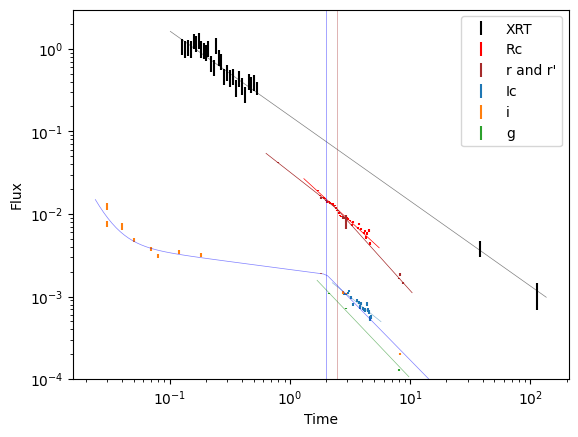

In [87]:
alz_xrt.plot_data(scale=1e10, color="k", label="XRT")
alz_xrt.plot_model(color="k", scale=1e10, lw=0.5, alpha=0.5)

alz_Rc.plot_data(scale=10, color="red", label="Rc")
alz_Rc.plot_model(color="red", scale=10, lw=0.5)

alz_r.plot_data(scale=10, color="brown", label="r and r'")
alz_r.plot_model(color="brown", scale=10, lw=0.5)
plt.axvline(alz_r.best_fit_params[1], color="brown", lw=0.5, alpha=0.5)

alz_Ic.plot_data(label="Ic")
alz_Ic.plot_model(color="C0", lw=0.5, alpha=0.5)

alz_i.plot_data(label="i")
alz_i.plot_model(color="blue", lw=0.5, alpha=0.5)
plt.axvline(alz_i.best_fit_params[3], color="blue", lw=0.5, alpha=0.5)


alz_g.plot_data(label="g")
alz_g.plot_model(color="green", lw=0.5, alpha=0.5)


plt.legend()

plt.ylim(1e-4,)
plt.show()

NameError: name 'df' is not defined

In [89]:
print("XRT", alz_xrt.best_fit_params)
print("Rc", alz_Rc.best_fit_params)
print("r", alz_r.best_fit_params)
print("Ic", alz_Ic.best_fit_params)
print("i", alz_i.best_fit_params)
print("g", alz_g.best_fit_params)


XRT [1.5325032950404544e-11, 1.0292361934504495]
Rc [0.003811474638082948, 1.3357691628763726]
r [0.0011593132062532535, 2.4412438785450163, 1.1402459187995233, 1.6204672660992312]
Ic [0.0037680984270095437, 1.1628391170605388]
i [3.9455187529761485e-08, 3.3518121597601214, 0.0018330686386611782, 2.0028779701609687, 0.1918698900659035, 1.4866259171789453, 0.014432032371887834]
g [0.0034729198838764318, 1.529040299483159]


In [90]:
df

,Starting Date,Time,Facility,Mag,Error,Filter,Exposure,Circular
42,2025-10-13 19:45:42,2.10,LCO,16.3,0.01,g,3x200,42229
93,2025-10-13 20:36:20,2.94,INO340,16.75,0.017,g,NaN,42492
219,2025-10-14 01:46:49,8.12,Liverpool Telescope,18.62,0.04,g,NaN,42334


In [53]:
df = read_data("circular")

In [58]:
df["Facility"].value_counts()

Facility
Leavitt                                    53
Calapai                                    40
Bassano Bresciano Observatory              40
MASTER-SAAO                                27
Osservatorio Astronomico "Nastro Verde"     8
NUTTelA-TAO                                 8
Mondy/AZT-33IK                              8
ISON-Castelgrande                           7
BOOTES-6/DPRT                               7
INO340                                      6
SAO/Zeiss-1000                              6
Liverpool Telescope                         5
LCO                                         5
SAO RAS                                     5
OHP/T193                                    4
Kilonova-Catcher                            3
SVOM/COLIBRÍ                                3
SVOM/VT                                     2
SYSU                                        2
Swift/UVOT                                  2
LAST                                        2
Asiago                   

In [56]:
df[df["Facility"]=="Bassano Bresciano Observatory"]

,Starting Date,Time,Facility,Mag,Error,Filter,Exposure,Circular
36,2025-10-13 19:38:51,1.99,Bassano Bresciano Observatory,15.63,0.01,clear,10x30,42262
37,2025-10-13 19:38:51,1.99,Bassano Bresciano Observatory,15.63,0.01,clear,10x30,42262
41,2025-10-13 19:44:06,2.07,Bassano Bresciano Observatory,15.67,0.01,clear,10x30,42262
46,2025-10-13 19:49:19,2.16,Bassano Bresciano Observatory,15.73,0.01,clear,10x30,42262
49,2025-10-13 19:54:33,2.25,Bassano Bresciano Observatory,15.72,0.01,clear,10x30,42262
53,2025-10-13 19:59:47,2.33,Bassano Bresciano Observatory,15.77,0.01,clear,10x30,42262
58,2025-10-13 20:05:01,2.42,Bassano Bresciano Observatory,15.84,0.01,clear,10x30,42262
62,2025-10-13 20:10:16,2.51,Bassano Bresciano Observatory,15.92,0.01,clear,10x30,42262
66,2025-10-13 20:15:30,2.60,Bassano Bresciano Observatory,15.98,0.01,clear,10x30,42262
73,2025-10-13 20:20:44,2.68,Bassano Bresciano Observatory,16.05,0.01,clear,10x30,42262


In [5]:
df = read_data("circular")
#df = filter_data(df, filter_name=filter_name, remove_upper_limits=True)


In [9]:
filter_data(df, filter_name="Rc")

,Starting Date,Time,Facility,Mag,Error,Filter,Exposure,Circular,Limit
25,2025-10-13 19:17:45.600,1.63,Leavitt,15.38,0.01,Rc,NaN,42333,False
27,2025-10-13 19:22:04.800,1.71,Leavitt,15.51,0.01,Rc,NaN,42333,False
28,2025-10-13 19:26:24.000,1.78,Leavitt,15.67,0.01,Rc,NaN,42333,False
31,2025-10-13 19:30:43.200,1.85,Leavitt,15.73,0.02,Rc,NaN,42333,False
33,2025-10-13 19:35:02.400,1.92,Leavitt,15.74,0.02,Rc,NaN,42333,False
35,2025-10-13 19:37:55.200,1.97,Leavitt,15.76,0.02,Rc,NaN,42333,False
39,2025-10-13 19:40:48.000,2.02,Leavitt,15.86,0.02,Rc,NaN,42333,False
41,2025-10-13 19:43:40.800,2.07,Leavitt,15.84,0.02,Rc,NaN,42333,False
44,2025-10-13 19:46:33.600,2.11,Leavitt,15.84,0.02,Rc,NaN,42333,False
45,2025-10-13 19:47:54.000,2.14,SAO RAS,15.84,0.01,Rc,300,42230,False
